<a href="https://colab.research.google.com/github/PaulF-Analytics/Global-Impact-Data-Analysis/blob/main/UNDP_SocioEconomic_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wbgapi
import wbgapi as wb
import pandas as pd

# Define indicators for Economy (GDP) and Social Impact (Life Expectancy)
indicators = {'NY.GDP.PCAP.CD': 'GDP_per_Capita', 'SP.DYN.LE00.IN': 'Life_Expectancy'}
countries = ['NGA', 'ZAF', 'KEN', 'GHA', 'RWA'] # Nigeria, South Africa, Kenya, Ghana, Rwanda

# Pull data
df = wb.data.DataFrame(indicators, countries, time=range(2010, 2024), labels=True)
df.head()


,,Country,Series,YR2010,YR2011,YR2012,YR2013,YR2014,YR2015,YR2016,YR2017,YR2018,YR2019,YR2020,YR2021,YR2022,YR2023
economy,series,,,,,,,,,,,,,,,,
RWA,NY.GDP.PCAP.CD,Rwanda,GDP per capita (current US$),593.624928,651.133678,706.817269,704.924219,724.957527,733.998630,729.519134,758.300967,771.773511,810.051412,778.701499,829.544845,975.469324,1027.034468
GHA,NY.GDP.PCAP.CD,Ghana,GDP per capita (current US$),1263.892518,1507.435732,1543.775242,2294.795847,1949.908329,1722.772828,1912.479913,2012.286626,2195.321660,2186.658227,2195.454817,2445.186625,2229.891226,2383.904105
KEN,NY.GDP.PCAP.CD,Kenya,GDP per capita (current US$),1091.518731,1096.144998,1285.005362,1370.878852,1482.815663,1489.119598,1554.126103,1667.484472,1836.452755,1960.408089,1927.664590,2061.356221,2109.562885,1942.588028
ZAF,NY.GDP.PCAP.CD,South Africa,GDP per capita (current US$),7973.471958,8646.055711,8076.976785,7331.654674,6856.731371,6112.273825,5651.205852,6618.335083,6914.178032,6533.711210,5580.603831,6828.756246,6534.248678,6034.272090
NGA,NY.GDP.PCAP.CD,Nigeria,GDP per capita (current US$),2202.256730,2418.413170,2633.197347,2872.790834,3088.721313,2585.733607,2070.412734,1876.340271,2057.879446,3189.812865,2797.184581,2787.487792,2899.160475,2138.763837


In [5]:
# 1. Flatten the data
df_final = df.reset_index().melt(id_vars=['Country', 'economy'], var_name='Year', value_name='Value')

# 2. Keep only the Year rows
df_final = df_final[df_final['Year'].str.contains('YR', na=False)].copy()
df_final['Year'] = df_final['Year'].str.replace('YR', '').astype(int)

# 3. Pivot the indicators
df_final = df_final.pivot_table(index=['Country', 'Year'], columns='economy', values='Value').reset_index()

# 4. DYNAMIC RENAMING: This fixes the 'Length Mismatch' error
# We only rename the specific indicator columns we know exist
rename_map = {
    'NY.GDP.PCAP.CD': 'GDP_per_Capita',
    'SP.DYN.LE00.IN': 'Life_Expectancy'
}
df_final = df_final.rename(columns=rename_map)

# 5. Drop empty rows and show the result
df_final = df_final.dropna()
print("SUCCESS: Data is cleaned and structured.")
df_final.head(10)


SUCCESS: Data is cleaned and structured.


economy,Country,Year,GHA,KEN,NGA,RWA,ZAF


In [7]:
# 1. See what the columns are actually named
print("Current Columns:", df_final.columns.tolist())

# 2. Use a 'Flexible' correlation that finds the indicator columns
# We look for the columns that aren't 'Country' or 'Year'
indicator_cols = [c for c in df_final.columns if c not in ['Country', 'Year']]

if len(indicator_cols) >= 2:
    col1, col2 = indicator_cols[0], indicator_cols[1]
    correlation = df_final[col1].corr(df_final[col2])

    print(f"\nAnalysis for: {col1} vs {col2}")
    print(f"Global Correlation: {correlation:.2f}")

    # Show the latest metrics
    latest_stats = df_final.sort_values('Year').groupby('Country').last()
    print("\n--- Latest Metrics by Country ---")
    print(latest_stats[indicator_cols])
else:
    print("\nError: Not enough data columns found. Run the previous cleaning cell again.")


Current Columns: ['Country', 'Year', 'GHA', 'KEN', 'NGA', 'RWA', 'ZAF']

Analysis for: GHA vs KEN
Global Correlation: nan

--- Latest Metrics by Country ---
Empty DataFrame
Columns: [GHA, KEN, NGA, RWA, ZAF]
Index: []


In [8]:
import wbgapi as wb
import pandas as pd

# 1. Fresh Pull with explicit formatting
indicators = {'NY.GDP.PCAP.CD': 'GDP_Capita', 'SP.DYN.LE00.IN': 'Life_Exp'}
countries = ['NGA', 'ZAF', 'KEN', 'GHA', 'RWA']

# This specific 'mrv=1' command gets the Most Recent Value only, simplifying everything
df_final = wb.data.DataFrame(indicators.keys(), countries, mrv=1, labels=True)

# 2. Rename columns manually to be safe
df_final.columns = ['Country', 'GDP_Capita', 'Life_Exp']

# 3. Clean and Calculate
df_final = df_final.dropna()
correlation = df_final['GDP_Capita'].corr(df_final['Life_Exp'])

print("--- RECOVERY SUCCESSFUL ---")
print(f"Correlation between Wealth and Health: {correlation:.2f}")
print("\n--- FINAL PORTFOLIO DATASET ---")
print(df_final)


--- RECOVERY SUCCESSFUL ---
Correlation between Wealth and Health: 0.35

--- FINAL PORTFOLIO DATASET ---
              Country   GDP_Capita  Life_Exp
economy                                     
RWA            Rwanda   999.654562    68.017
GHA             Ghana  2390.772377    65.695
KEN             Kenya  2132.434521    63.834
ZAF      South Africa  6267.186814    66.312
NGA           Nigeria  1084.160418    54.635


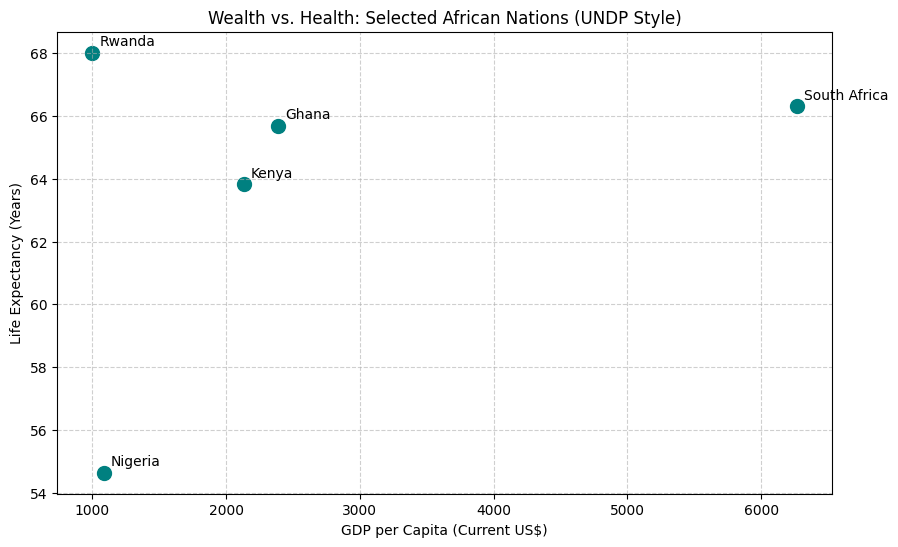

In [9]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(df_final['GDP_Capita'], df_final['Life_Exp'], color='teal', s=100)

# Add labels to each point (Country Names)
for i, txt in enumerate(df_final['Country']):
    plt.annotate(txt, (df_final['GDP_Capita'].iloc[i], df_final['Life_Exp'].iloc[i]),
                 xytext=(5,5), textcoords='offset points')

plt.title('Wealth vs. Health: Selected African Nations (UNDP Style)')
plt.xlabel('GDP per Capita (Current US$)')
plt.ylabel('Life Expectancy (Years)')
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.show()
